In [2]:
import matplotlib.pyplot as plt
import numpy as np
import zarr

def getP(flow_array):
    
    x = flow_array[:, :, :, 0]  # x成分
    y = flow_array[:, :, :, 1]  # y成分
    # ベクトルの大きさを計算
    magnitude = np.sqrt(x**2 + y**2)

    # --- 1. Polar Order Parameter (P) の計算 ---
    # 全ベクトルの平均を計算
    mean_x = np.mean(x, axis=(1,2))
    mean_y = np.mean(y, axis=(1,2))
        
    # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
    # P = |<v>| / <|v|>
    mean_magnitude_of_vectors = np.mean(magnitude, axis=(1,2))
    magnitude_of_mean_vector = np.sqrt(mean_x**2 + mean_y**2)

    P = magnitude_of_mean_vector / mean_magnitude_of_vectors
    return P

path1 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_zarr/MTs_flow.zarr'
path2 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr/MTs_flow.zarr'
path3 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260107/MTs_flow.zarr'

flow1 = zarr.open_array(path1, mode='r')
flow2 = zarr.open_array(path2, mode='r')
flow3 = zarr.open_array(path3, mode='r')

P1 = getP(flow1)
P2 = getP(flow2)
P3 = getP(flow3)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_26205/2896276422.py:22: RuntimeWarning: invalid value encountered in divide
  P = magnitude_of_mean_vector / mean_magnitude_of_vectors


[Text(0.5, 0, 'Polar Order Parameter (P)'),
 Text(0, 0.5, 'Density'),
 (-0.01, 1.0),
 (0.0, 7.0)]

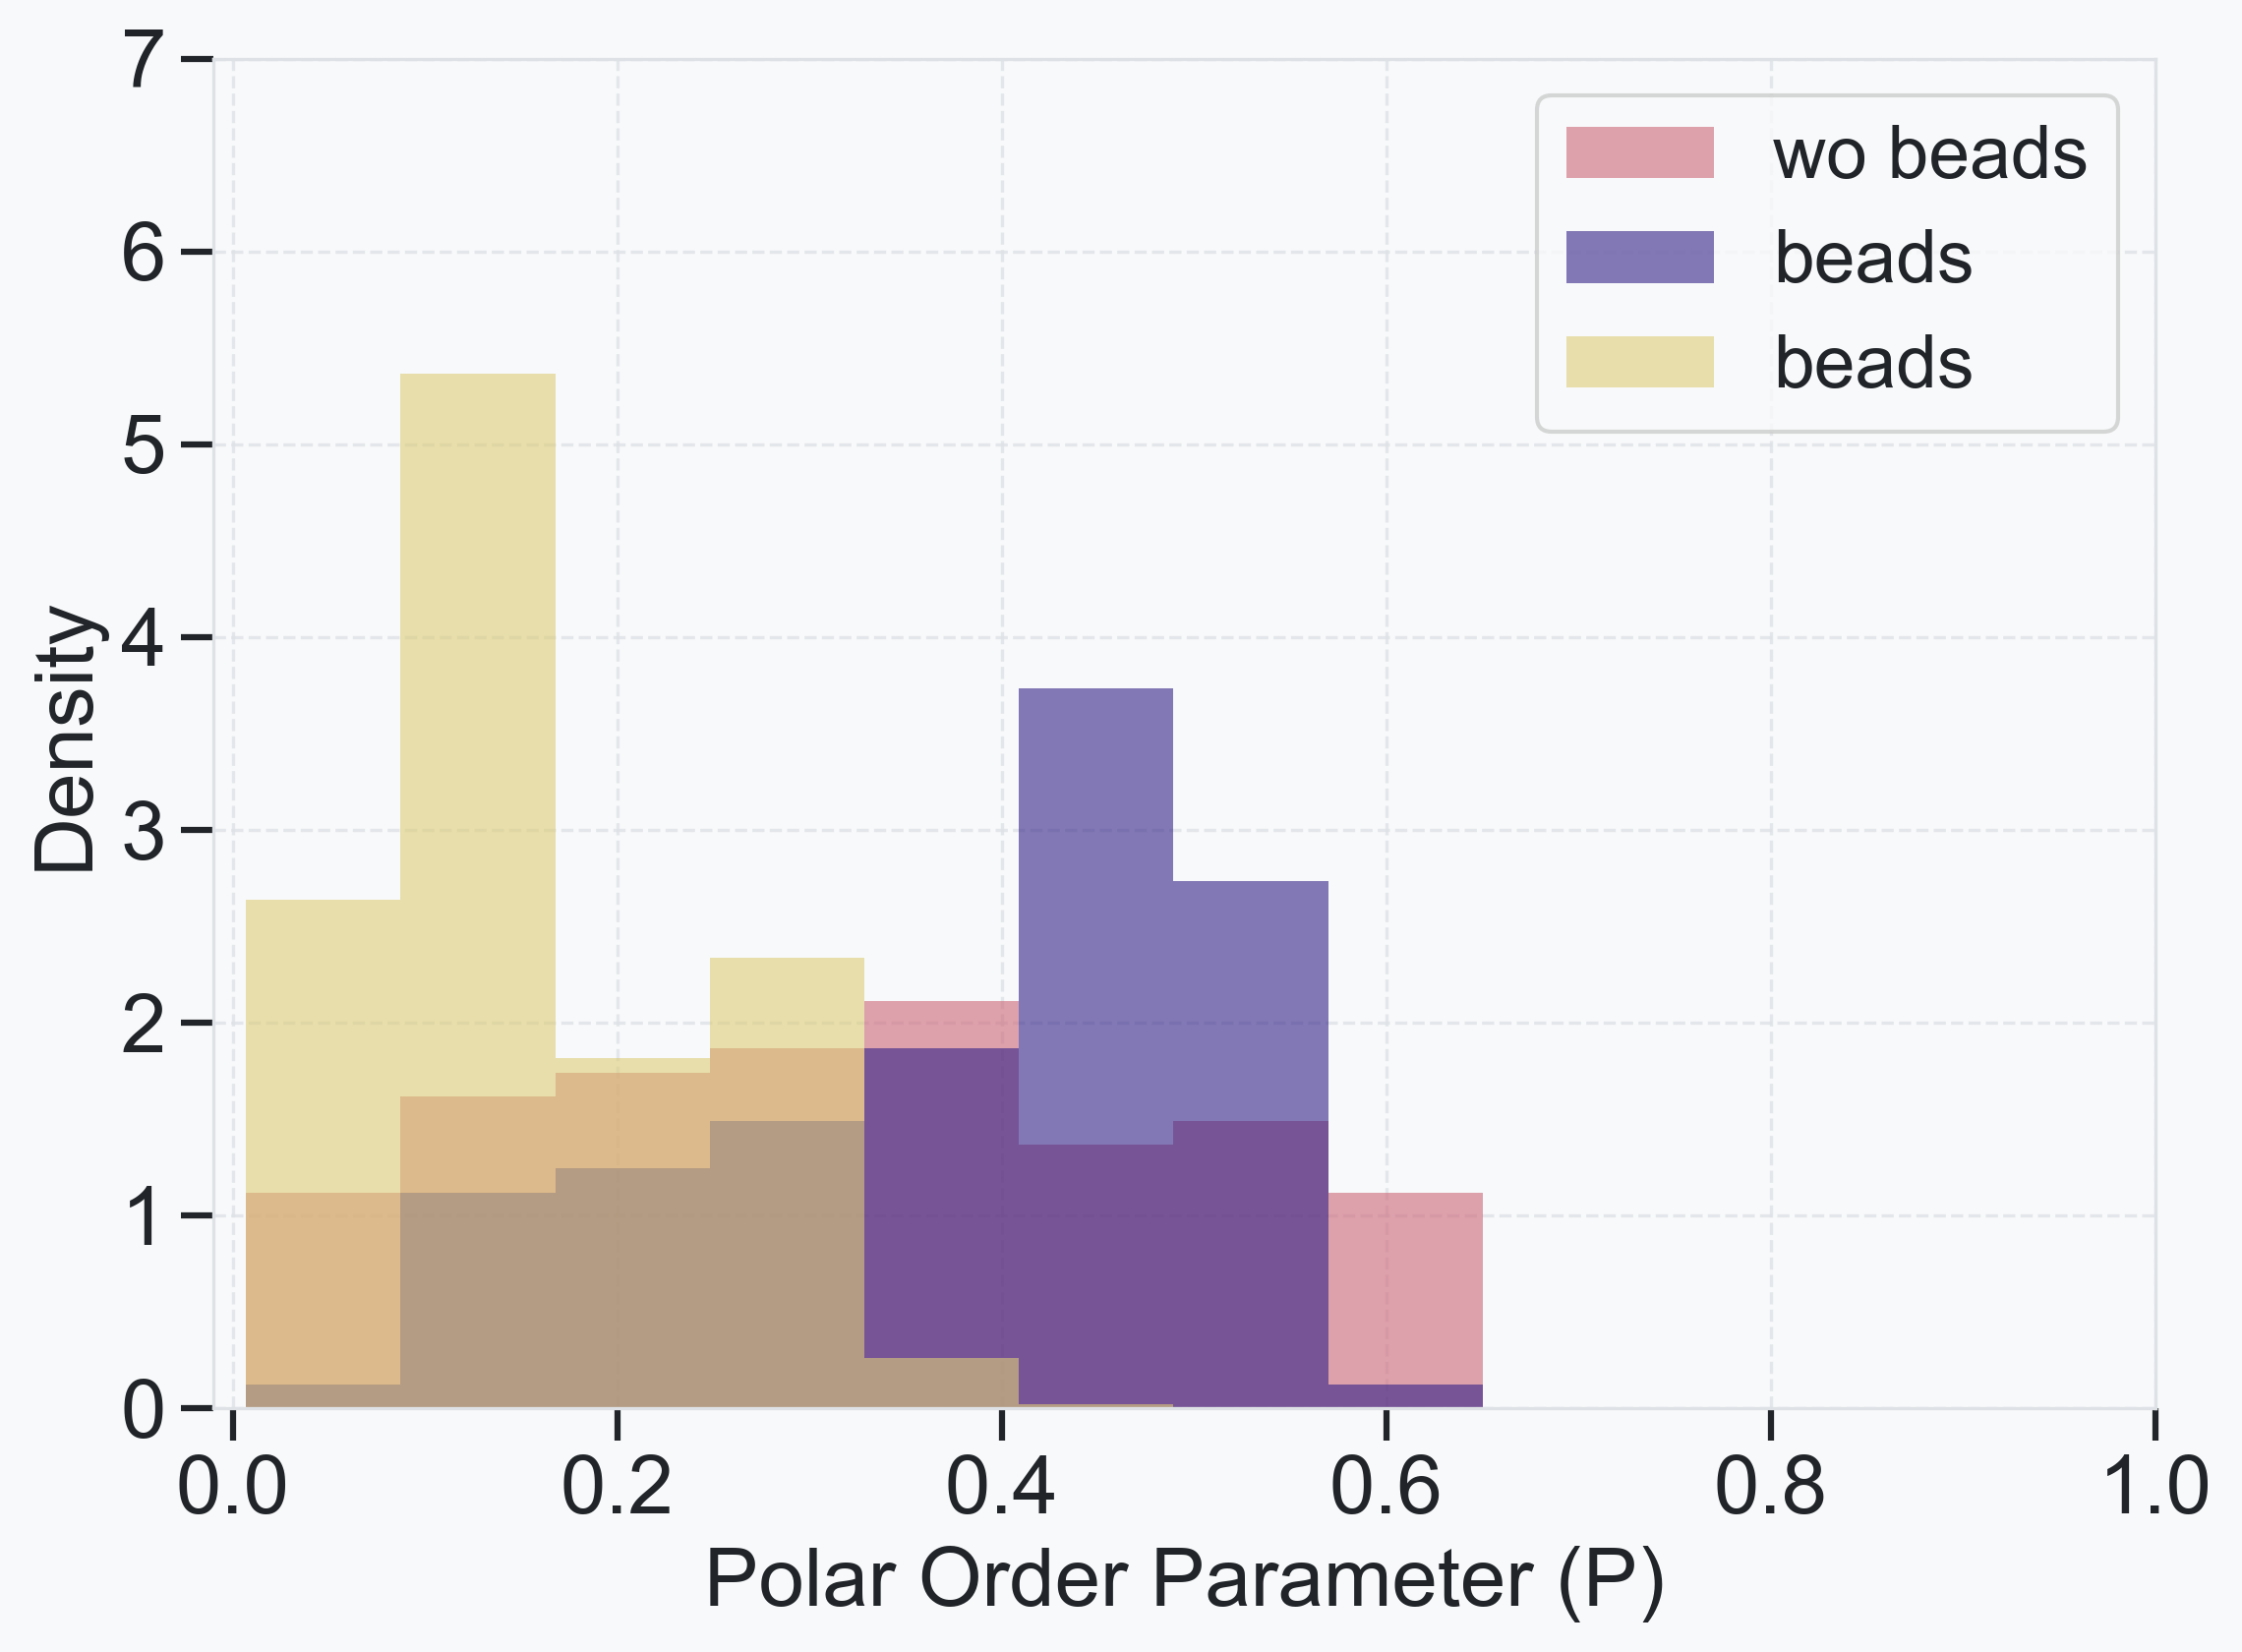

In [23]:
bins = np.histogram_bin_edges(P1[:-1], bins='sturges')
alpha = 0.6

plt.style.use('../libs/my_style.mplstyle')

fig, ax = plt.subplots()
ax.hist(P1[:-1], bins, density=True, label='wo beads', alpha = alpha)
ax.hist(P2[:-1], bins, density=True, label='beads', alpha = alpha)
ax.hist(P3[:-1], bins, density=True, label='beads', alpha = alpha)

ax.legend()

ax.set(xlabel='Polar Order Parameter (P)',
        ylabel='Density',
        xlim=(-0.01,1),
        ylim=(0,7)
       )

#fig.savefig(f'/Users/sasakinozomu/Documents/analysis/Output/P_hist.png', bbox_inches='tight')

[Text(0.5, 0, 'Time t [s]'),
 Text(0, 0.5, 'Polar Order Parameter (P)'),
 (-0.01, 1000.0),
 (0.0, 1.0)]

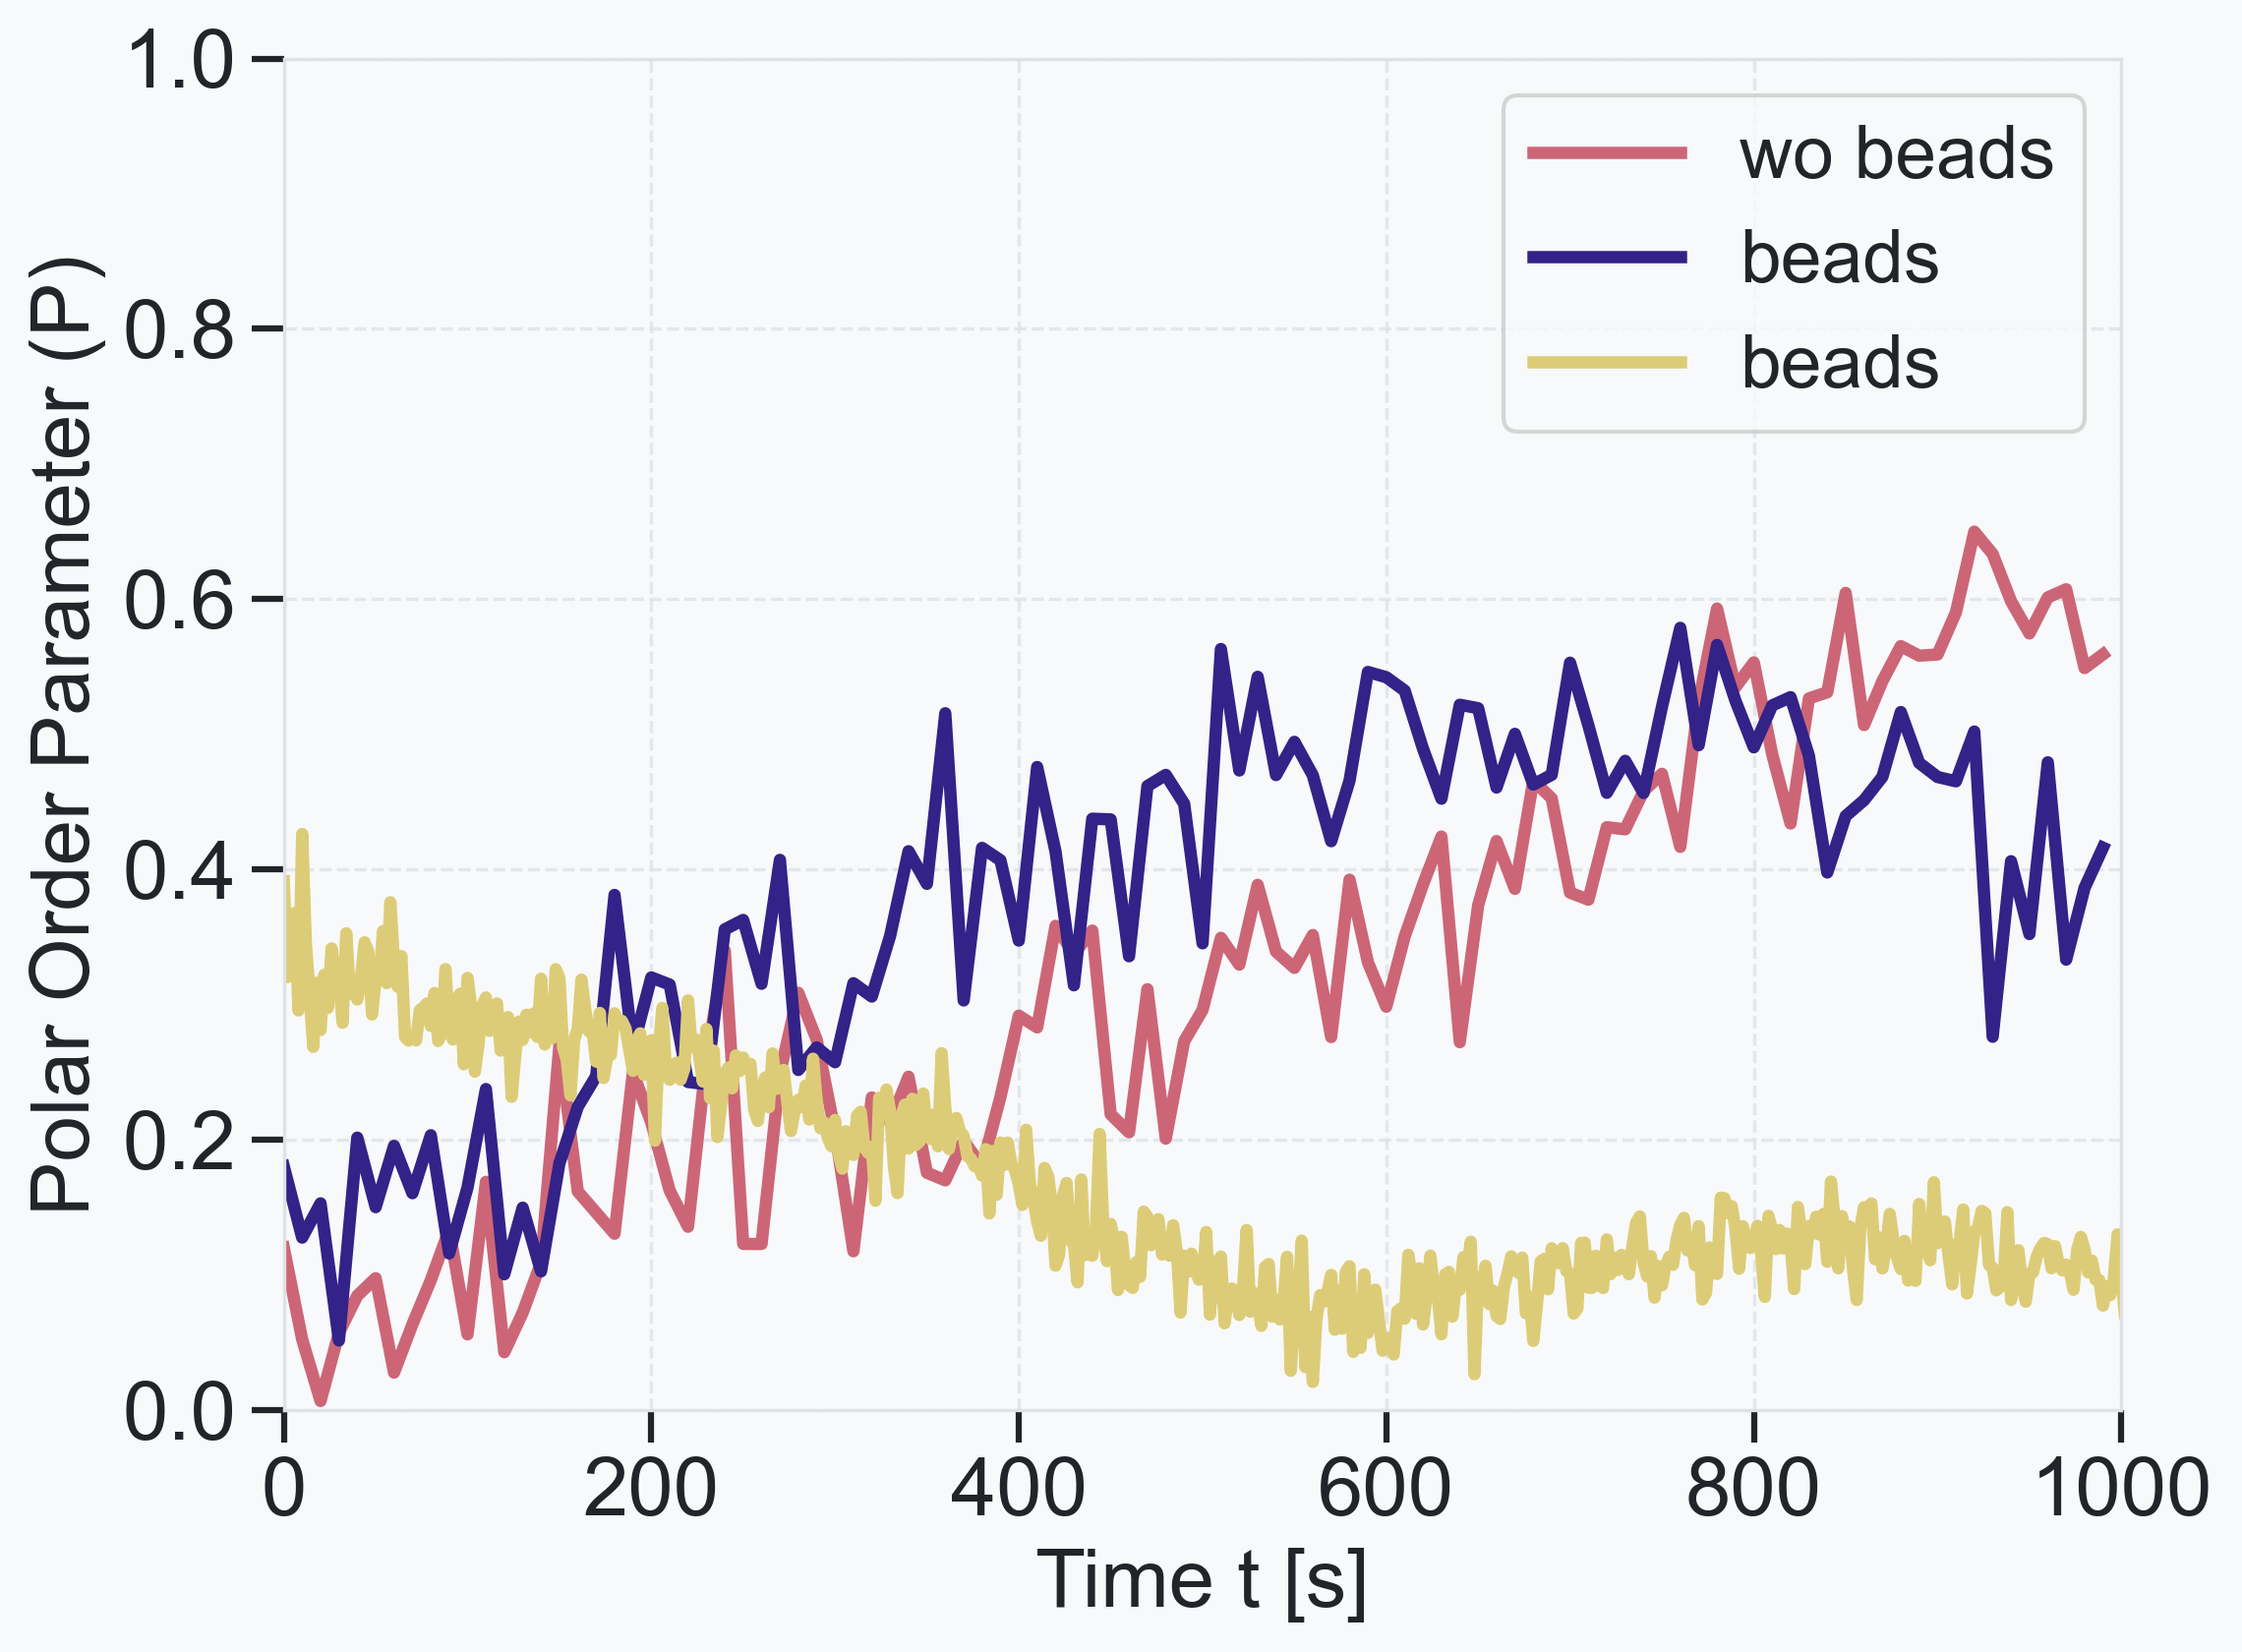

In [29]:
fig, ax = plt.subplots()

ax.plot(10*np.arange(P1.shape[0]-1), P1[:-1], label='wo beads')
ax.plot(10*np.arange(P2.shape[0]-1), P2[:-1], label='beads')
ax.plot(2*np.arange(P3.shape[0]-1), P3[:-1], label='beads')

ax.legend()

ax.set(xlabel='Time t [s]',
        ylabel='Polar Order Parameter (P)',
        xlim=(-0.01,1e3),
        ylim=(0,1)
       )